In [19]:
import numpy as np
import matplotlib.pyplot as plt

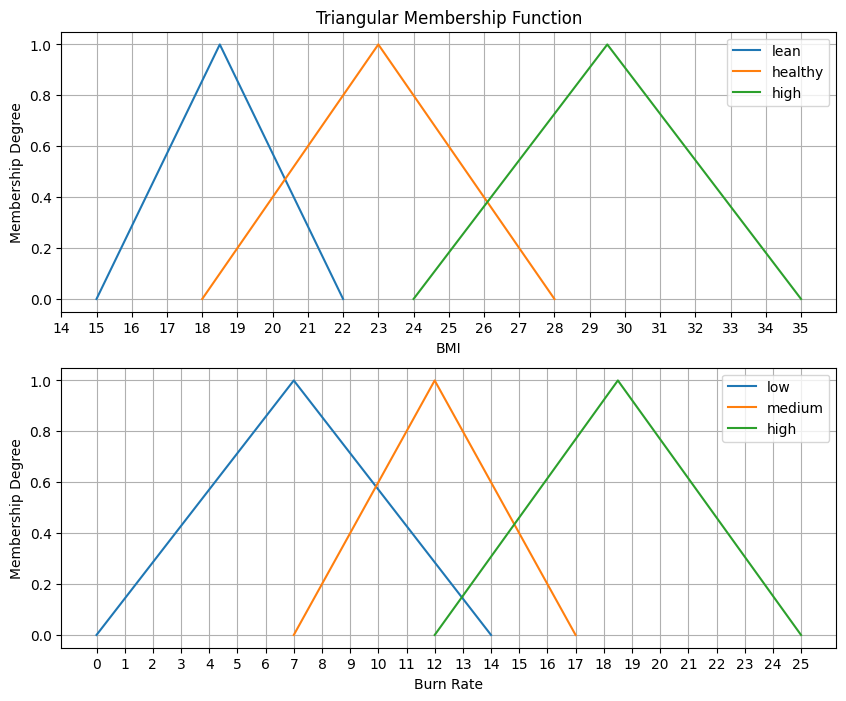

In [20]:
# Input Define:
n=1+1
bmi={
    'lean':[15,22],
    'healthy':[18,28],
    'high':[24,35]
}

# Output Define:
burn_rate={
    'low':[0,14],
    'medium':[7,17],
    'high':[12,25]
}

y=[0,1,0]
plt.figure(figsize=(10,8))
plt.subplot(n,1,1)
plt.xticks(np.arange(14,36,1))
plt.grid(True)
plt.title('Triangular Membership Function')
plt.xlabel('BMI')
plt.ylabel('Membership Degree')
for i,j in bmi.items():
    x=[]
    for k in j:
        x.append(k)
    x.insert(1,np.sum(j)/2)
    plt.plot(x,y,label=i)
    plt.legend()

plt.subplot(n,1,2)
plt.xticks(np.arange(0,26,1))
plt.grid(True)
plt.xlabel('Burn Rate')
plt.ylabel('Membership Degree')
for i,j in burn_rate.items():
    x=[]
    for k in j:
        x.append(k)
    x.insert(1,np.sum(j)/2)
    plt.plot(x,y,label=i)
    plt.legend()
    
plt.show()

In [21]:
def rules(value):
    if(value=='healthy'):
        return np.sum(burn_rate['medium'])/2
    elif(value=='high'):
        return np.sum(burn_rate['high'])/2
    elif(value=='lean'):
        return np.sum(burn_rate['low'])/2
    
    

In [22]:
def membership_degree(x,s):
    a=bmi[s][0] # minimum value
    b=np.mean(bmi[s]) # mid value
    c=bmi[s][1] #max value
    if x>=c:
        return 0
    if x>b:
        return (c-x)/(c-b)
    if x>a:
        return (x-a)/(b-a)
    else:
        return 0

In [23]:
def Fuzzy(x):
    membership_value=[]
    for i,j in bmi.items():
        result=membership_degree(x,i) # take the membership value from given input
        membership_value.append(result)

    print(membership_value)

    crisp_burn=[]
    for i in bmi:
        crisp_burn.append(rules(i)) # storing the rule
        
    crisp_burn=np.array(crisp_burn)
    try:
        crisp_burn=crisp_burn*np.array(membership_value) #multiplication
        crisp_burn=np.sum(crisp_burn)/np.sum(membership_value) # Divide
    except:
        crisp_burn=0
    
    return crisp_burn


In [24]:
x=26
print(f"{Fuzzy(x):.3f}")

[0, np.float64(0.4), np.float64(0.36363636363636365)]
15.095
